# **BLOCO 1**
# Modelos de Aprendizado de Máquina e Redes Neurais (Aula Prática)

Nesta aula vamos treinar **quatro modelos de Machine Learning**.
A ideia é sempre seguir o **mesmo padrão**:

1. Carregar o dataset  
2. Criar o modelo  
3. Treinar o modelo (`fit`)  
4. Fazer previsões (`predict`)  
5. Visualizar os resultados  

Modelos da aula:

- Regressão Linear
- Regressão Logística
- Árvore de Decisão
- K-Means

Experimente você mesmo (no final de cada modelo):
- Alterações do código: clicar na área de edição e alterar

Exercício com Redes Neurais (ex: MLP,CNN):
- Construir modelos de rede neurais para os problemas acima

Exercícios desafios (avançados):
- Incluir ajustes de hiperparâmetros (com validação cruzada) para redes neurais criadas
- Incluir métricas e visualizações adicionais para cada modelo criado
- Construir análise comparativa entre os modelos

**As atividades práticas não são avaliativas, mas devem ser entregues da seguinte forma para obtenção de feedback pelo monitor da disciplina:**
- Entregar arquivo ipynb ou link para notebook compartilhado para leitura
- O notebook deve incluir os resultados da execução, bem como explicações sobre os passos realizados   

# Importando bibliotecas

Usaremos apenas algumas bibliotecas simples.

In [1]:
import pandas as pd # importando biblioteca pandas, ja fizemos isso na ultima aula!
import matplotlib.pyplot as plt # importando biblioteca matplotlib, já fizemos isso na ultima aula!

from sklearn.model_selection import train_test_split # novidade aqui, importando o train_test_split
from sklearn.metrics import accuracy_score # outra novidade, importando o accuracy!

# 1️⃣ Regressão Linear

A regressão linear é usada para **prever números**.

Exemplo: prever o **preço de casas**.

Vamos usar o dataset **California Housing**. Esse dataset vem do censo da Califórnia de 1990 e cada linha representa uma pequena região dentro da California.

In [2]:
from sklearn.datasets import fetch_california_housing # vamos usar o dataset California Housing
from sklearn.linear_model import LinearRegression # vamos usar a regressão linear, que é um dos tipos de modelo de aprendizado de máquina

dataset_california_housing = fetch_california_housing(as_frame=True).frame # pega os dados (que não vem de um csv) e coloca em um dataframe pandas

In [3]:
# vamos entender melhor esses dados
dataset_california_housing.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### Explicação das colunas

- **MedInc** ->	renda média das famílias da região
- **HouseAge** ->	idade média das casas do bairro
- **AveRooms** ->	número médio de cômodos por casa
- **AveBedrms** ->	número médio de quartos de dormir
- **Population** ->	população total da região censitária
- **AveOccup** ->	média de moradores por residência
- **Latitude** ->	coordenada geográfica norte-sul
- **Longitude** ->	coordenada geográfica leste-oeste
- **MedHouseValue** ->	valor médio das casas da região em centenas de milhares de dólares

In [4]:
colunas_house = dataset_california_housing[["MedInc"]]   # vamos tentar prever o preço (nosso alvo) usando só a coluna/feature MedInc
alvo_house = dataset_california_housing["MedHouseVal"] # nosso alvo, o preço da casa

In [5]:
colunas_house

,MedInc
0,8.3252
1,8.3014
2,7.2574
3,5.6431
4,3.8462
...,...
20635,1.5603
20636,2.5568
20637,1.7000
20638,1.8672


In [6]:
alvo_house

,MedHouseVal
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422
...,...
20635,0.781
20636,0.771
20637,0.923
20638,0.847


### Por que separar em treino e teste?

Imagine que você vai fazer uma prova amanhã.
Você passa a noite estudando as questões **da própria prova**.
No dia seguinte, acerta tudo — mas isso prova que você aprendeu ou só que memorizou?

Com modelos de Machine Learning é a mesma coisa.
Se treinarmos e avaliarmos o modelo nos **mesmos dados**, ele vai parecer ótimo
porque "decorou" as respostas... e vai falhar miseravelmente em dados novos.

Para evitar isso, dividimos os dados em dois grupos:

- **Treino**: os dados que o modelo vai usar para aprender
- **Teste**: dados que o modelo **nunca viu** durante o treino, usados apenas para avaliação

O `train_test_split` faz essa divisão automaticamente, de forma aleatória.

Uma divisão típica é **80% treino / 20% teste**, mas isso pode variar conforme o tamanho do dataset.

In [7]:
colunas_house_treino, colunas_house_teste, alvo_house_treino, alvo_house_teste = train_test_split(colunas_house, alvo_house, test_size=0.01) # divide em treino e teste. Teste só 1% do database

In [8]:
modelo_house = LinearRegression() # aqui estamos dizendo que queremos usar a Regressão Linear
modelo_house.fit(colunas_house_treino, alvo_house_treino) # a função fit é a que faz o treino, ou seja, momento que o modelo começa a aprender com os dados
pred = modelo_house.predict(colunas_house_teste) # com o modelo treinado, podemos predizer o valor das casas de teste

In [9]:
pred # valor das casas preditas de teste

array([1.97306319, 1.83122968, 2.59256589, 2.47978463, 3.26825022,
       1.13071508, 6.72174787, 1.8596131 , 1.49865454, 2.19862571,
       2.35789058, 2.516194  , 1.30356553, 1.55048878, 1.00702355,
       3.25470643, 1.92265022, 1.09112878, 1.37780553, 2.27775652,
       2.13496157, 1.59676337, 1.68262427, 1.47666679, 1.56800373,
       2.10607652, 1.76576806, 0.95552373, 2.12083256, 3.33634535,
       1.2727158 , 1.71171833, 1.33236697, 1.17448157, 1.28592517,
       2.38021274, 2.67140409, 1.65582932, 2.18378607, 1.33224157,
       2.80366499, 2.66525923, 1.86563256, 1.23354752, 1.66368806,
       2.01152085, 1.45292337, 2.7551749 , 2.78564841, 2.54202751,
       2.01089382, 3.87500337, 1.21870788, 3.32083688, 1.37500481,
       2.31161598, 2.40913959, 1.26134571, 2.48927364, 1.57268553,
       1.75581923, 1.48899833, 1.63058103, 1.42884553, 2.11105094,
       3.28710283, 2.33251688, 2.52434535, 1.3816931 , 2.76591796,
       1.28299905, 1.41287724, 1.87512157, 1.2818704 , 1.51257

### Avaliando

In [10]:
print("\nExemplos de previsão:\n")

for i in range(5):
    print("Valor real: $", alvo_house_teste.iloc[i])
    print("Valor predito: $", pred[i])
    print("----")


Exemplos de previsão:

Valor real: $ 2.675
Valor predito: $ 1.9730631904169875
----
Valor real: $ 1.938
Valor predito: $ 1.8312296770240015
----
Valor real: $ 2.297
Valor predito: $ 2.5925658925932478
----
Valor real: $ 2.673
Valor predito: $ 2.479784631427826
----
Valor real: $ 2.724
Valor predito: $ 3.2682502163433877
----


Quão bem foi o modelo? Para isso vamos usar o MAE. O MAE é o erro absoluto médio. É a média dos erros.

MAE = média(valor real−valor predito)



In [11]:
from sklearn.metrics import mean_absolute_error # importamos o MAE para poder usa-lo

erro = mean_absolute_error(alvo_house_teste, pred)
print("Erro médio absoluto:", erro)

Erro médio absoluto: 0.569898621209516


#### Entendendo o resultado da avaliação

Esse erro médio mostra que o modelo erra em média $60.000 por predição que ele faz

## Visualizando a regressão

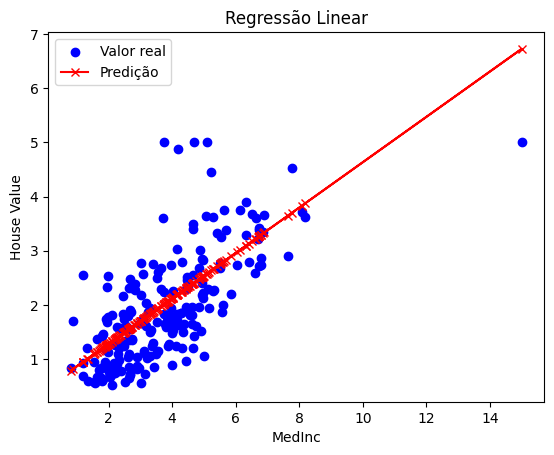

In [12]:
plt.scatter(colunas_house_teste, alvo_house_teste, color="blue", marker="o", label="Valor real") # scatter é o "gráfico de bolinhas". Dizemos a cor, o tipo de marcador e o rótulo (label)
plt.plot(colunas_house_teste, pred, color="red", marker="x", linestyle="-", label="Predição") # plot é o "gráfico de linha". Dizemos a cor, o marcador, tipo do tracejado e o rótulo (label)

plt.xlabel("MedInc")
plt.ylabel("House Value")
plt.title("Regressão Linear")
plt.legend()

plt.show()

### Dicas

- Para ver quais datasets temos disponiveis no sklearn, basta acessar esse link https://scikit-learn.org/stable/datasets.html

### Experimente você mesmo!

**1. Troque a feature e veja o impacto no erro:**
```python
# Tente usar "HouseAge" ou "AveRooms" no lugar de "MedInc" e compare o MAE
colunas_house = dataset_california_housing[["HouseAge"]]
```

**2. Use duas features ao mesmo tempo:**
```python
# O modelo melhora quando damos mais informações para ele?
colunas_house = dataset_california_housing[["MedInc", "AveRooms"]]
```

**3. Aumente o tamanho do conjunto de teste:**
```python
# Troque test_size=0.01 por test_size=0.2 — as previsões tem melhores resultados?
train_test_split(colunas_house, alvo_house, test_size=0.2)
```

# 2️⃣ Regressão Logística

Apesar do nome, a regressão logística é usada para **classificação**.

Exemplo: prever se um tumor é **maligno ou benigno**.

Vamos usar o dataset **Breast Cancer**.

In [13]:
# importando as bibliotecas necessarias
from sklearn.datasets import load_breast_cancer # dataset cancer de mama
from sklearn.linear_model import LogisticRegression # modelo de regressão logística
from sklearn.metrics import accuracy_score # métricas nova: acurácia


In [14]:
dataset_breast_cancer = load_breast_cancer(as_frame=True).frame # carrega o dataset e transforma em um dataset pandas


In [15]:
dataset_breast_cancer.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [16]:
dataset_breast_cancer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

### Explicação das colunas

- **mean radius** -> raio médio do tumor
- **mean texture** ->	variação média da textura
- **mean perimeter** ->	perímetro médio do tumor
- **mean area** ->	área média do tumor
- **mean smoothness** ->	suavidade média da borda
- **mean compactness** ->	densidade média da massa
- **mean concavity** ->	profundidade média das concavidades
- **target** -> câncer de mama (1) ou não (0)

In [17]:
# separar features e target. Daqui para frente chamaremos dessa maneira
features = dataset_breast_cancer.drop(columns=["target"]) # features: todas as colunas do dataset, menos a coluna target
target = dataset_breast_cancer["target"] # target: a coluna que vai dizer se é cancer ou não

In [18]:
# separar em treino e teste
features_treino, features_teste, target_treino, target_teste = train_test_split(features, target, test_size=0.1) # 10% do nosso dataset vai ser usado para teste e os outros 90% para treinar o modelo

In [19]:
modelo_breast_cancer = LogisticRegression() # criando o modelo de Regressão Logística

In [20]:
modelo_breast_cancer.fit(features_treino, target_treino) # treino usando a função fit

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [21]:
pred = modelo_breast_cancer.predict(features_teste) # predição do set de teste usando a função predict

In [22]:
print("\nExemplos de previsão:\n")

for i in range(5):
    print("Valor real:", target_teste.iloc[i])
    print("Valor predito:", pred[i])
    print("-----")


Exemplos de previsão:

Valor real: 1
Valor predito: 1
-----
Valor real: 1
Valor predito: 1
-----
Valor real: 1
Valor predito: 1
-----
Valor real: 0
Valor predito: 0
-----
Valor real: 0
Valor predito: 0
-----


In [23]:
# acurácia
accuracy = accuracy_score(target_teste, pred)
print("Accuracy:", accuracy)

Accuracy: 0.9649122807017544


### Entendendo o resultado

A acurácia de X% significa que o modelo acertou **X% dos diagnósticos**.

Em outras palavras: uma acurácia de 94% siginifica que de cada 100 tumores analisados, ele errou apenas 6.

Para um problema médico, isso parece ótimo, mas cuidado: acurácia sozinha pode enganar.
Imagine um dataset onde 94% dos casos são benignos. Um modelo burro que sempre responde
"benigno" teria 94% de acurácia sem aprender nada.

Por isso, em problemas médicos costumamos usar métricas adicionais.

## Comparando previsões

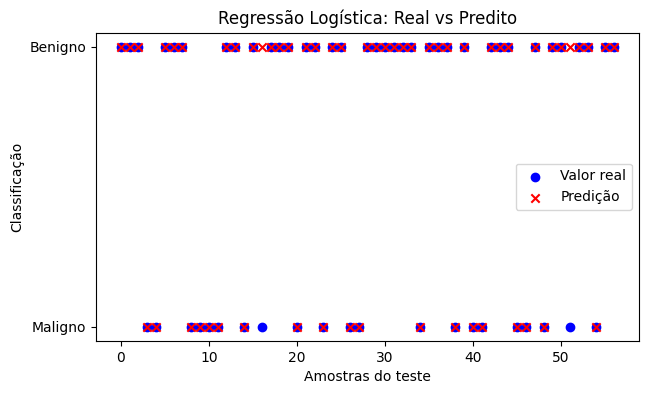

In [24]:
plt.figure(figsize=(7,4)) # figsize é o tamanho da figura

plt.scatter(range(len(target_teste)), target_teste,
            marker="o", color="blue", label="Valor real") # gráfico de pontos, marcador "bolinha", cor azul, para os valores reais do dataset

plt.scatter(range(len(pred)), pred,
            marker="x", color="red", label="Predição") # gráfico de pontos, marcador "em X", cor vermelha, para os valores que foram preditos pelo nosso modelo

plt.yticks([0,1], ["Maligno", "Benigno"])
plt.xlabel("Amostras do teste")
plt.ylabel("Classificação")
plt.title("Regressão Logística: Real vs Predito")

plt.legend()
plt.show()

### Explicando o Resultado

A regressão logística calcula a probabilidade de algo pertencer a uma classe.

Se a probabilidade passar de 50%, o modelo escolhe aquela classe.

Imagine um médico analisando um tumor.
Ele não pensa "é benigno ou maligno" imediatamente.

Ele pensa algo como:

*“Parece benigno com 80% de chance.”*

A regressão faz exatamente isso, mas usando matemática.

### Experimente você mesmo!

**1. Remova a coluna mais importante e veja a acurácia cair:**
```python
# "mean radius" é uma das features mais relevantes. O que acontece sem ela?
features = dataset_breast_cancer.drop(columns=["target", "mean radius"])
```

**2. Use metade dos dados para teste:**
```python
# O que acontece com a acurácia quando o modelo tem menos dados para treinar?
train_test_split(features, target, test_size=0.5)
```

# 3️⃣ Árvore de Decisão

Árvores de decisão funcionam como **fluxogramas de decisão**.

Vamos usar novamente o dataset **Titanic**.

In [25]:
from sklearn.tree import DecisionTreeClassifier # importa a biblioteca de Árvore de Decisão

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
dataset_titanic = pd.read_csv(url)
dataset_titanic = dataset_titanic[["Pclass","Sex","Age","Fare","Survived"]] # escolhe quais colunas do Titanic vai usar

In [26]:
dataset_titanic.head()

,Pclass,Sex,Age,Fare,Survived
0,3,male,22.0,7.2500,0
1,1,female,38.0,71.2833,1
2,3,female,26.0,7.9250,1
3,1,female,35.0,53.1000,1
4,3,male,35.0,8.0500,0


In [27]:
print("Valores faltantes por coluna:\n")
print(dataset_titanic.isnull().sum())

Valores faltantes por coluna:

Pclass        0
Sex           0
Age         177
Fare          0
Survived      0
dtype: int64


In [28]:
dataset_titanic["Sex"] = dataset_titanic["Sex"].map({"male":0,"female":1}) # aqui deixamos o valor 0 como masculino e 1 como feminino. A árvore de decisão não entende "palavras" aqui

In [29]:
dataset_titanic = dataset_titanic.dropna() # remove todas as linhas que estão vazias, ou seja, todas as linhas que tem alguém sem idade

In [30]:
dataset_titanic.head()

,Pclass,Sex,Age,Fare,Survived
0,3,0,22.0,7.2500,0
1,1,1,38.0,71.2833,1
2,3,1,26.0,7.9250,1
3,1,1,35.0,53.1000,1
4,3,0,35.0,8.0500,0


In [31]:
features = dataset_titanic[["Pclass","Sex","Age","Fare"]] # define quais são nossas features
target = dataset_titanic["Survived"] # define qual é nosso target

In [32]:
features_treino, features_teste, target_treino, target_teste = train_test_split(features, target, test_size=0.2) # divide em treino (80%) e teste (20%)

In [33]:
modelo_titanic = DecisionTreeClassifier(max_depth=3) # aqui diz que usaremos uma árvore de classificação com profundidade 3

In [34]:
modelo_titanic.fit(features_treino, target_treino) # treina o modelo

DecisionTreeClassifier(max_depth=3)

In [35]:
pred = modelo_titanic.predict(features_teste) # faz as predições

In [36]:
print("\nExemplos de previsão:\n")

for i in range(5):
    print("Valor real:", target_teste.iloc[i])
    print("Valor predito:", pred[i])
    print("-----")


Exemplos de previsão:

Valor real: 1
Valor predito: 1
-----
Valor real: 1
Valor predito: 1
-----
Valor real: 1
Valor predito: 0
-----
Valor real: 1
Valor predito: 0
-----
Valor real: 0
Valor predito: 0
-----


In [37]:
accuracy = accuracy_score(target_teste, pred)
print("\nAccuracy:", accuracy)


Accuracy: 0.8321678321678322


## Visualizando previsões

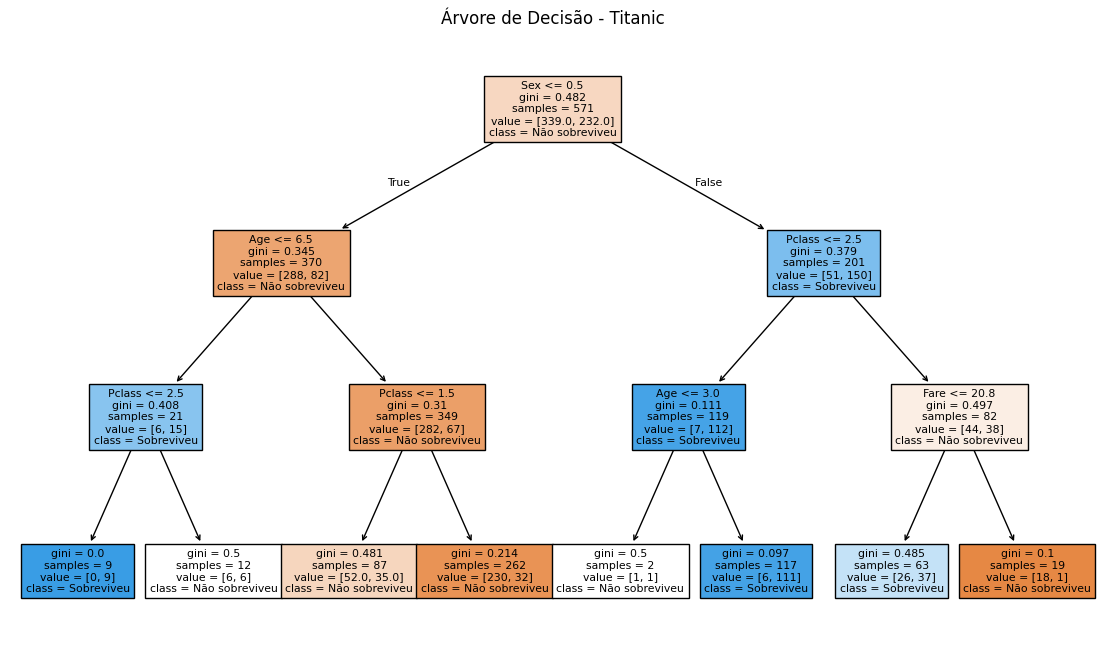

In [38]:
from sklearn import tree
plt.figure(figsize=(14,8))

tree.plot_tree(
    modelo_titanic,
    feature_names=["Pclass","Sex","Age","Fare"],
    class_names=["Não sobreviveu","Sobreviveu"],
    filled=True
)

plt.title("Árvore de Decisão - Titanic")
plt.show()

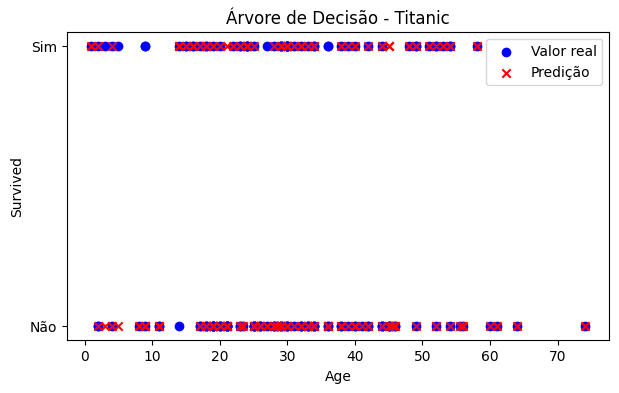

In [39]:
plt.figure(figsize=(7,4))

plt.scatter(features_teste["Age"], target_teste,
            color="blue", marker="o", label="Valor real")

plt.scatter(features_teste["Age"], pred,
            color="red", marker="x", label="Predição")

plt.xlabel("Age")
plt.ylabel("Survived")
plt.yticks([0,1], ["Não", "Sim"])
plt.title("Árvore de Decisão - Titanic")

plt.legend()
plt.show()

### Experimente você mesmo!

**1. Mude a profundidade da árvore:**
```python
# Tente max_depth=1, max_depth=5 e max_depth=10 — o que acontece com a acurácia?
# Dica: uma árvore muito profunda "decora" os dados de treino e vai mal no teste
modelo_titanic = DecisionTreeClassifier(max_depth=1)
```

**2. Remova a coluna "Sex" e veja o impacto:**
```python
# Sexo foi um critério real de embarque nos botes salva-vidas.
# O modelo piora muito sem essa informação?
features = dataset_titanic[["Pclass", "Age", "Fare"]]
```

**3. Plote a árvore com profundidade 1 — fica pequena e fácil de ler:**
```python
modelo_titanic_simples = DecisionTreeClassifier(max_depth=1)
modelo_titanic_simples.fit(features_treino, target_treino)

tree.plot_tree(
    modelo_titanic_simples,
    feature_names=["Pclass", "Sex", "Age", "Fare"],
    class_names=["Não sobreviveu", "Sobreviveu"],
    filled=True
)
plt.show()
```

# 4️⃣ K-Means (Clustering)

Diferente dos outros modelos, o **K-Means não usa rótulos**.

Ele tenta **descobrir grupos automaticamente** nos dados.

In [40]:
from sklearn.datasets import load_iris # caregga o dataset IRIS
from sklearn.cluster import KMeans # carrega o modelo KMeans

dataset_iris = load_iris(as_frame=True).frame # transforma o dataset IRIS em um dataset pandas

In [41]:
dataset_iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### Explicação das colunas

- **sepal length (cm):**	comprimento da sépala da flor
- **sepal width (cm):**	largura da sépala da flor
- **petal length (cm):**	comprimento da pétala
- **petal width (cm)**	largura da pétala
- **target:**	espécie da flor (0 → Setosa; 1 → Versicolor; 2 → Virginica)

In [42]:
features = dataset_iris.drop(columns=["target"]) # nossas features: todas as colunas, exceto o target, ou seja, sepal length, sepal width, petal length, petal width
target = dataset_iris["target"] # coluna target aqui é a espécie da flor

In [43]:
modelo_kmeans = KMeans(n_clusters=3) # estamos dizendo que queremos usar o K Means e formar 3 grupos

In [44]:
# treino
modelo_kmeans.fit(features)

KMeans(n_clusters=3)

In [45]:
# prever clusters
pred = modelo_kmeans.predict(features)

In [46]:
print("\nExemplos de clusterização:\n")

for i in range(5):
    print("Classe real:", target.iloc[i])
    print("Cluster encontrado:", pred[i])
    print("-----")


Exemplos de clusterização:

Classe real: 0
Cluster encontrado: 1
-----
Classe real: 0
Cluster encontrado: 1
-----
Classe real: 0
Cluster encontrado: 1
-----
Classe real: 0
Cluster encontrado: 1
-----
Classe real: 0
Cluster encontrado: 1
-----


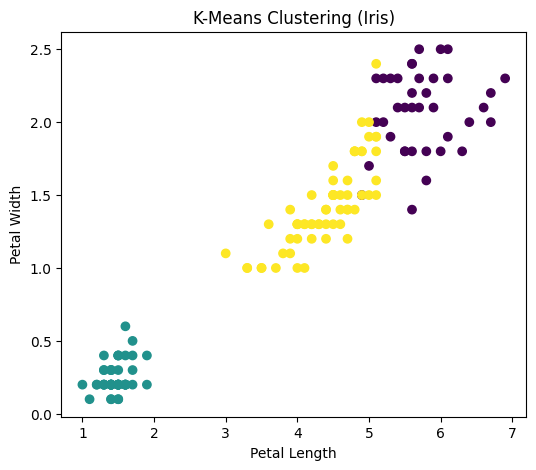

In [47]:
plt.figure(figsize=(6,5))

plt.scatter(
    features["petal length (cm)"],
    features["petal width (cm)"],
    c=pred,
    cmap="viridis",
    marker="o"
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("K-Means Clustering (Iris)")

plt.show()

## Visualizando os clusters

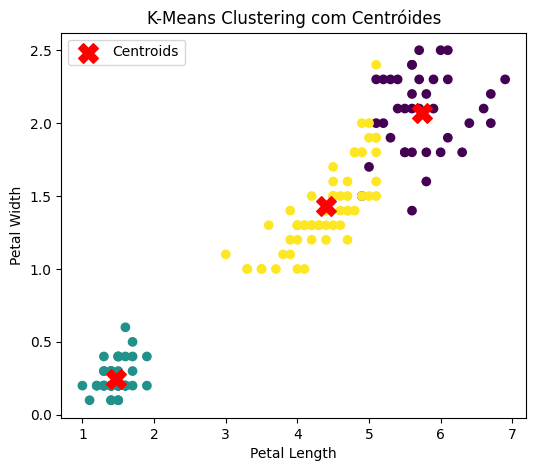

In [48]:
centroids = modelo_kmeans.cluster_centers_

plt.figure(figsize=(6,5))

plt.scatter(
    features["petal length (cm)"],
    features["petal width (cm)"],
    c=pred,
    cmap="viridis",
    marker="o"
)

plt.scatter(
    centroids[:,2],
    centroids[:,3],
    color="red",
    marker="X",
    s=200,
    label="Centroids"
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("K-Means Clustering com Centróides")

plt.legend()
plt.show()

### 🧪 Experimente você mesmo!

**1. Mude o número de clusters:**
```python
# O que acontece quando pedimos 2 grupos? E 5 grupos?
# O modelo vai tentar se virar de qualquer jeito — mas vai fazer sentido?
modelo_kmeans = KMeans(n_clusters=2)
```

# Conclusão e próximos passos

Treinamos quatro modelos:
- **Regressão Linear**
- **Regressão Logística**
- **Árvore de Decisão**
- **K-Means**

Todos seguem o mesmo padrão:

model = Modelo()  
model.fit(X, y)  
model.predict(X)

# Incluir abaixo
Exercício com Redes Neurais (MLP ou CNN):
- **Construir modelos de rede neurais para os problemas acima**

Exercícios desafios (avançados):

-	**Incluir ajustes de hiperparâmetros (com validação cruzada) para cada rede neural**
-	**Incluir métricas e visualizações adicionais para cada modelo criado**
-	**Construir análise comparativa entre os modelos**

# Importante
As atividades práticas não são avaliativas, mas devem ser entregues da seguinte forma para obtenção de feedback pelo monitor da disciplina:
- **Entregar arquivo ipynb ou link para notebook compartilhado para leitura**
- **O notebook deve incluir os resultados da execução, bem como explicações sobre os passos realizados**

